In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("car_data.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [8]:
df = df.drop_duplicates()

In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Driven_kms     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Selling_type   299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


In [11]:
#  feature engineering 

In [87]:
# Create a Car_Age feature (assuming a baseline or current comparison year like 2024 or 2026)
df['Car_Age'] = 2026 - df['Year']

C:\Users\HP\AppData\Local\Temp\ipykernel_5648\3341792941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Car_Age'] = 2026 - df['Year']


In [89]:
# visualization

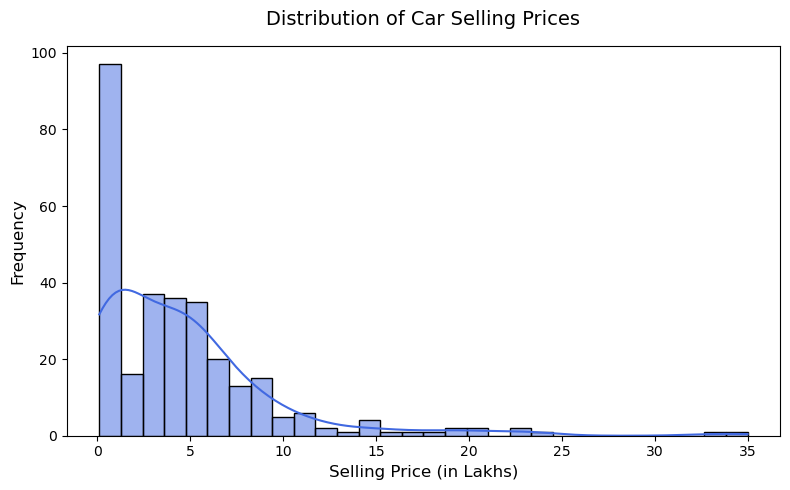

In [91]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of Car Selling Prices', fontsize=14, pad=15)
plt.xlabel('Selling Price (in Lakhs)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('eda_selling_price_distribution.png')
plt.show()

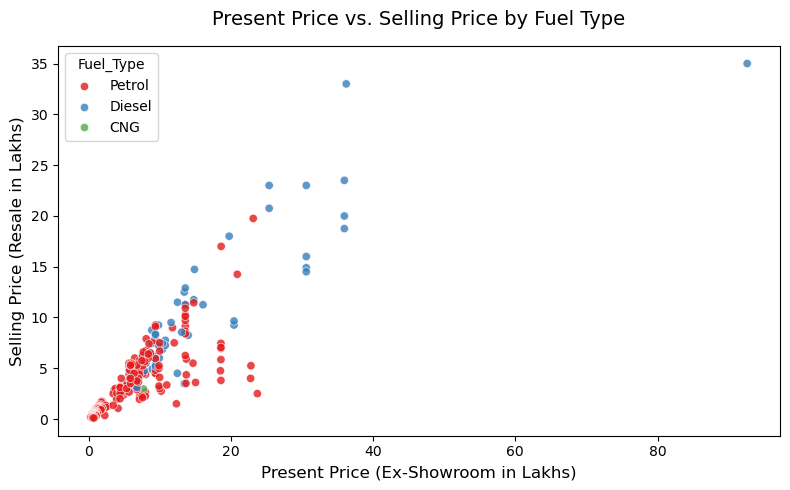

In [92]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df, hue='Fuel_Type', palette='Set1', alpha=0.8)
plt.title('Present Price vs. Selling Price by Fuel Type', fontsize=14, pad=15)
plt.xlabel('Present Price (Ex-Showroom in Lakhs)', fontsize=12)
plt.ylabel('Selling Price (Resale in Lakhs)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_present_vs_selling_price.png')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_5648\2588933344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Transmission', y='Selling_Price', data=df, order=transmission_order, palette='Pastel1')


Text(0, 0.5, 'Selling Price (in Lakhs)')

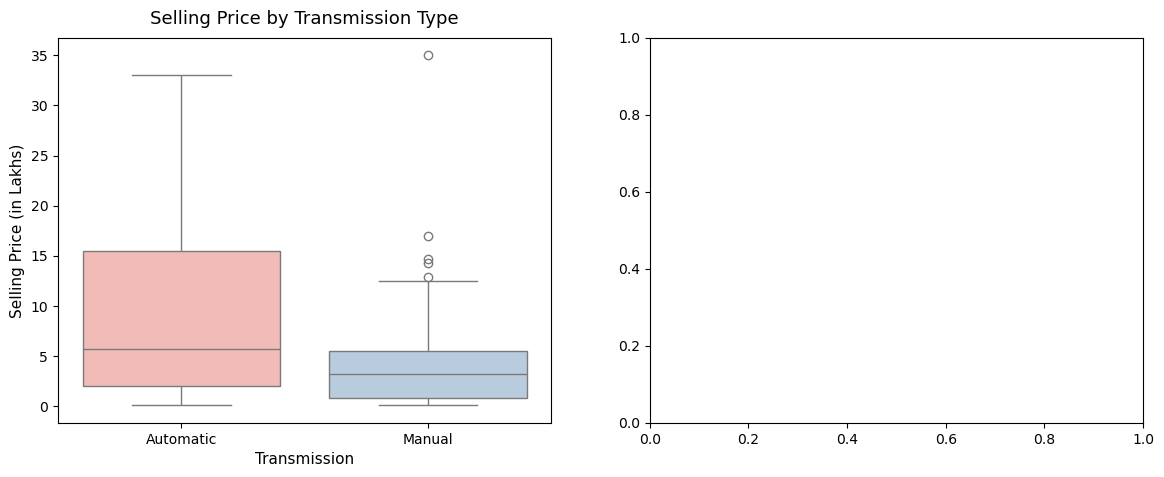

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
transmission_order = df.groupby('Transmission')['Selling_Price'].median().sort_values(ascending=False).index
sns.boxplot(ax=axes[0], x='Transmission', y='Selling_Price', data=df, order=transmission_order, palette='Pastel1')
axes[0].set_title('Selling Price by Transmission Type', fontsize=13, pad=10)
axes[0].set_xlabel('Transmission', fontsize=11)
axes[0].set_ylabel('Selling Price (in Lakhs)', fontsize=11)

In [95]:
selling_order = df.groupby('Selling_type')['Selling_Price'].median().sort_values(ascending=False).index
sns.boxplot(ax=axes[1], x='Selling_type', y='Selling_Price', data=df, order=selling_order, palette='Pastel2')
axes[1].set_title('Selling Price by Seller Type', fontsize=13, pad=10)
axes[1].set_xlabel('Seller Type', fontsize=11)
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('eda_categorical_analysis.png')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_5648\1590595865.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='Selling_type', y='Selling_Price', data=df, order=selling_order, palette='Pastel2')


<Figure size 640x480 with 0 Axes>

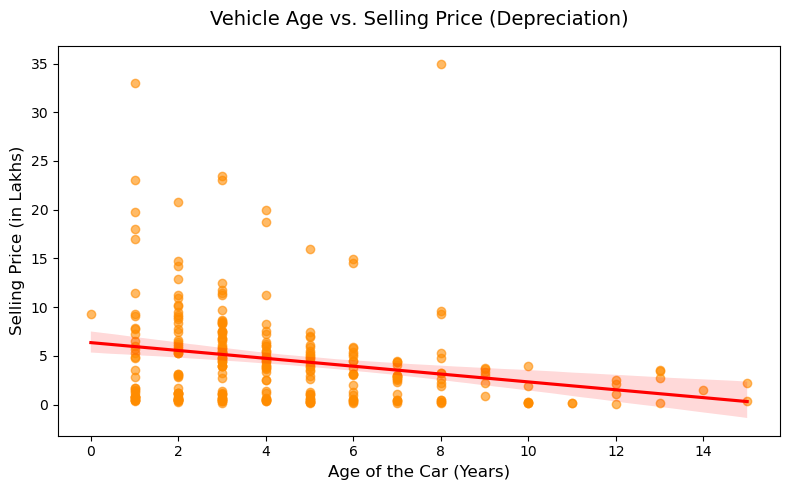

In [96]:
plt.figure(figsize=(8, 5))
sns.regplot(x='Age', y='Selling_Price', data=df, color='darkorange', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Vehicle Age vs. Selling Price (Depreciation)', fontsize=14, pad=15)
plt.xlabel('Age of the Car (Years)', fontsize=12)
plt.ylabel('Selling Price (in Lakhs)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_age_vs_price.png')
plt.show()

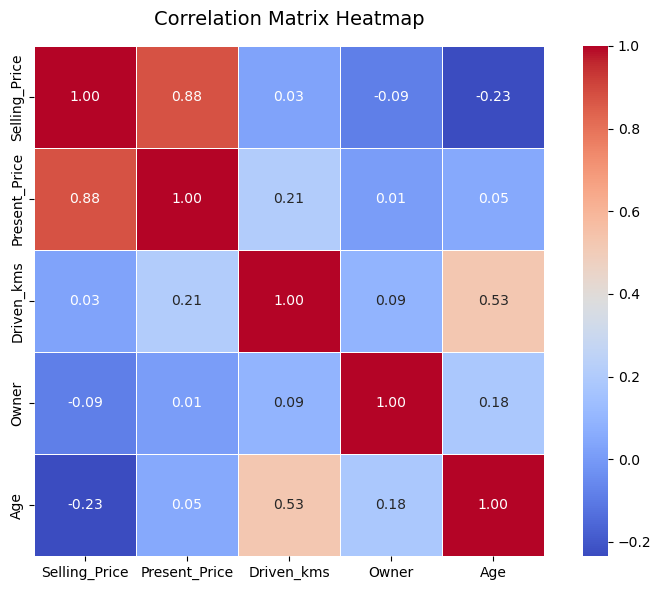

In [98]:
plt.figure(figsize=(8, 6))
numerical_cols = ['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Age']
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title('Correlation Matrix Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png')
plt.show()

In [101]:
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,5,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,7,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,4,12
...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,2,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,3,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,9,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,1,9


In [102]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [104]:
features_to_use = ['Year', 'Present_Price', 'Driven_kms', 'Owner', 'Fuel_Type', 'Transmission', 'Selling_type', 'Selling_Price']
df_filtered = df[features_to_use]

In [105]:
df_encoded = pd.get_dummies(df_filtered, drop_first=True)

In [106]:
X = df_numeric.drop(columns=['Selling_Price'])
y = df_numeric['Selling_Price']

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [114]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [116]:
predictions = model.predict(X_test)
accuracy = r2_score(y_test, predictions)

In [117]:
print("Model Accuracy (R2 Score):", accuracy)

Model Accuracy (R2 Score): 0.4869235990584728
